**Vector Search with Faiss**

**For me :**

 >ANN = graph (NOT Model | instead the specification of Arcs, Nodes,...)

>BeamSearch = One of the most optimal way to access closest neighbours of the querry

>HNSW, IVF, IVFPQ and IVFOPQ = method of pruning the graph (efficiency should depends on how the data is clustered) for then make the ANN.

The methods (HNSW, IVF,...) base (beginning)
themselves either on an approximate ANN - the way of adding node one by one during to construct the graph or else.

Setting-UP

In [1]:
!pip install faiss-cpu numpy matplotlib pandas

In [2]:
#Go down is a specific command to retrieve others drive file
!pip install gdown
!gdown --id 11qTbDKx4tJ97EgAFZOyIzNRhlX0fV-K_
import zipfile

with zipfile.ZipFile("Data_utils.zip", "r") as zip_ref:
    zip_ref.extractall("Drive_utils")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=11qTbDKx4tJ97EgAFZOyIzNRhlX0fV-K_
From (redirected): https://drive.google.com/uc?id=11qTbDKx4tJ97EgAFZOyIzNRhlX0fV-K_&confirm=t&uuid=6b01f959-0dc2-4552-9b77-3c326c7669c0
To: /content/Data_utils.zip
100% 162M/162M [00:03<00:00, 48.0MB/s]




---


**Part 0: Exact Baseline and Ground Truth**

*utils.py*

In [3]:
# @title
import numpy as np


def recall_at_k(pred_ids: np.ndarray, gt_ids: np.ndarray, k: int) -> float:
    pred = np.asarray(pred_ids, dtype=np.int64)
    gt = np.asarray(gt_ids, dtype=np.int64)
    if pred.ndim != 2 or gt.ndim != 2:
        raise ValueError("pred_ids and gt_ids must be 2D arrays of shape (nq, k_or_more).")
    if pred.shape[0] != gt.shape[0]:
        raise ValueError("pred_ids and gt_ids must have the same number of queries.")

    vals = []
    for p, g in zip(pred, gt):
        vals.append(len(set(map(int, p[:k])).intersection(map(int, g[:k]))) / float(k))
    return float(np.mean(vals))

*from bruteforce_gt_sample.py MODIFIED*

In [4]:
# @title
#import mon_script  if I want to use some of the classes
#!/usr/bin/env python3
import os
from pathlib import Path
import time

import numpy as np


DATASET_DIR = Path("datasubset100k")
K = 10
BATCH_SIZE = 100
OUT_SUBDIR = f"gt_k{K}"
DB_NORM = "dataset_stemwiki_100000_384_norm.bin"
Q_NORM = "queries_stemwiki_1000_384_norm.bin"


def load_vector_bin(path: Path) -> np.ndarray:
    with path.open("rb") as f:
        n = int(np.fromfile(f, dtype=np.int64, count=1)[0])
        d = int(np.fromfile(f, dtype=np.int64, count=1)[0])
        vec = np.fromfile(f, dtype=np.float32, count=n * d).reshape(n, d)
    return vec


def topk_ip_batch(xb: np.ndarray, xq: np.ndarray, k: int) -> np.ndarray:
    sims = xq @ xb.T
    part = np.argpartition(sims, -k, axis=1)[:, -k:]
    part_scores = np.take_along_axis(sims, part, axis=1)
    order = np.argsort(part_scores, axis=1)[:, ::-1]
    ids = np.take_along_axis(part, order, axis=1)
    return ids.astype(np.int64)


def compute_gt_ids(xb: np.ndarray, xq: np.ndarray, k: int, batch_size: int) -> np.ndarray:
    nq = xq.shape[0]
    gt = np.empty((nq, k), dtype=np.int64)
    for s in range(0, nq, batch_size):
        e = min(s + batch_size, nq)
        gt[s:e] = topk_ip_batch(xb, xq[s:e], k)
    return gt


def resolve_dataset_dir() -> Path:
    env_path = os.environ.get("TP_DATASET_DIR")
    if env_path:
        p = Path(env_path).expanduser()
        if p.exists():
            return p

    if DATASET_DIR.exists():
        return DATASET_DIR

    for cand in (
        Path("data/tp_binary_sets/subset_100k"),
        Path("subset_100k"),
        Path("datasubset100k"),
    ):
        if cand.exists():
            return cand

    raise FileNotFoundError(
        "Could not find dataset folder. Set TP_DATASET_DIR or edit DATASET_DIR in this file."
    )


def main() -> None:
    """
    base_dir =
    db_path = base_dir / DB_NORM
    q_path = base_dir / Q_NORM
    if not db_path.exists() or not q_path.exists():
        raise FileNotFoundError(
            f"Missing normalized vectors: {db_path} or {q_path}. "
            "Run examples/prepare_normalized_ip_bins.py first."  )
    """
    base_dir =Path("/content/Drive_utils/data")
    xb = load_vector_bin(Path("/content/Drive_utils/data/dataset_stemwiki_100000_384_norm.bin")).astype(np.float32)
    xq = load_vector_bin(Path("/content/Drive_utils/data/queries_stemwiki_1000_384_norm.bin")).astype(np.float32)


    t0 = time.perf_counter()
    gt_ids = compute_gt_ids(xb, xq, K, BATCH_SIZE)
    dt = time.perf_counter() - t0
    qps = xq.shape[0] / dt

    out_dir = base_dir / OUT_SUBDIR
    out_file = out_dir / "gt_ids.npy"
    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_file, gt_ids)
    recall_self = recall_at_k(gt_ids, gt_ids, K)

    print("Brute-force GT done")
    print(f"dataset_dir: {base_dir}")
    print(f"db shape: {xb.shape}, query shape: {xq.shape}")
    print(f"metric: IP (input vectors already normalized), k: {K}, batch_size: {BATCH_SIZE}")
    print(f"time_sec: {dt:.6f}, qps: {qps:.2f}")
    print(f"recall@{K} sanity check vs itself: {recall_self:.4f}")
    print(f"saved: {out_file}")


if __name__ == "__main__":
    main()

Brute-force GT done
dataset_dir: /content/Drive_utils/data
db shape: (100000, 384), query shape: (1000, 384)
metric: IP (input vectors already normalized), k: 10, batch_size: 100
time_sec: 6.193260, qps: 161.47
recall@10 sanity check vs itself: 1.0000
saved: /content/Drive_utils/data/gt_k10/gt_ids.npy


recall@10 sanity check vs itself = 1 as expected. These result will serve as a baseline.

In [5]:
# @title
import importlib
from pathlib import Path

def recall_at_k(pred_ids: np.ndarray, gt_ids: np.ndarray, k: int) -> float:
    pred = np.asarray(pred_ids, dtype=np.int64)
    gt = np.asarray(gt_ids, dtype=np.int64)
    if pred.ndim != 2 or gt.ndim != 2:
        raise ValueError("pred_ids and gt_ids must be 2D arrays of shape (nq, k_or_more).")
    if pred.shape[0] != gt.shape[0]:
        raise ValueError("pred_ids and gt_ids must have the same number of queries.")

    vals = []
    for p, g in zip(pred, gt):
        vals.append(len(set(map(int, p[:k])).intersection(map(int, g[:k]))) / float(k))
    return float(np.mean(vals))
gt_ids_path = Path("/content/Drive_utils/data/gt_k10/gt_ids.npy")

# Load the numpy arrays from the paths
gt_ids = np.load(gt_ids_path)
recall_at_k(gt_ids, gt_ids, k=10)

1.0



---


**Part 1: HNSW – Search Tradeoff and Build-Parameter Impact**

*from hnsw_example.py*

**FOR efConstruction ∈ {10 to 150} at fixed M**

In [6]:
# @title
#baseline HNSW index with M=24 and eConstruction=64
#!/usr/bin/env python3
from pathlib import Path
import time
import faiss
import numpy as np


def main() -> None:
    n = 10_000
    nq = 100
    d = 384 # Changed from 64 to 384 to match the vector dimension
    k = 10
    #This code is for random set of data it's extremely optimized [4 millions qps]
    #rng = np.random.default_rng(123)
    #xb = rng.standard_normal((n, d), dtype=np.float32)
    #xq = rng.standard_normal((nq, d), dtype=np.float32)
    xb = load_vector_bin(Path("/content/Drive_utils/data/dataset_stemwiki_100000_384_norm.bin")).astype(np.float32)
    xq = load_vector_bin(Path("/content/Drive_utils/data/queries_stemwiki_1000_384_norm.bin")).astype(np.float32)


    # Normalize once; then IP == cosine similarity.
    xb /= np.maximum(np.linalg.norm(xb, axis=1, keepdims=True), 1e-12)
    xq /= np.maximum(np.linalg.norm(xq, axis=1, keepdims=True), 1e-12) #Queries

    out_dir = Path("examples/indices")
    out_dir.mkdir(parents=True, exist_ok=True)

    #Pre-construction of the index
    M=24
    index = faiss.IndexHNSWFlat(d, M, faiss.METRIC_INNER_PRODUCT)
    index.hnsw.efConstruction = 64
    t0 = time.perf_counter()
    index.add(xb) # The graphe is crated THERE !!
    dt = time.perf_counter() - t0
    print(f"INDEX construction takes : {dt}s")

    #d -> vector dimension
    #M -> nb of neighbours of each nodes for the HNSW graph
    #METRIC_INNER_PRODUCT => PS used for measurement
    #efConstruction -> nb of candidates it will check to select the closest nodes

    eSearch_taken_values=np.arange(10,160,10)
    #eSearch -> the max number of candidates in the pile (see course very related to its inner working)
    for el in eSearch_taken_values:

      index.hnsw.efSearch = int(el)

      # Save under a diff name each for each efSearch

      index_path = out_dir / f"hnsw_10k_ip_ef{el}.faiss"
      faiss.write_index(index, str(index_path))

      reloaded = faiss.read_index(str(index_path))


      #To calculate qps :
      t0 = time.perf_counter()
      _, ids = reloaded.search(xq, k) #Select the 10 closest nodes for each query in xq
      reloaded.hnsw.efSearch = int(el)
      dt = time.perf_counter() - t0
      qps = xq.shape[0] / dt # xq.shape[0] = total nb of querries taken

      print(f"For efSearch={el} => qps={qps}")



      print("Index type:", index.__class__)
      print("Is trained:", index.is_trained)
      print("ntotal:", index.ntotal)

      print(f"Index saved to: {index_path}")
      print(f"Metric: IP (with normalized vectors)")
      print(f"Search results shape: {ids.shape}")
      print("Top-10 ids for each query:")
      for qi, row in enumerate(ids[-5:]):
          print(f"q{qi:03d}: {row.tolist()}")


if __name__ == "__main__":
    main()

INDEX construction takes : 47.947015607998765s
For efSearch=10 => qps=5053.17274291363
Index type: <class 'faiss.swigfaiss_avx2.IndexHNSWFlat'>
Is trained: True
ntotal: 100000
Index saved to: examples/indices/hnsw_10k_ip_ef10.faiss
Metric: IP (with normalized vectors)
Search results shape: (1000, 10)
Top-10 ids for each query:
q000: [20653, 10413, 98357, 45515, 35116, 6619, 63937, 16515, 67492, 16963]
q001: [1512, 58866, 52433, 40382, 26617, 80360, 77665, 17365, 67931, 68211]
q002: [34348, 72649, 93808, 92443, 46973, 27813, 77492, 2922, 6141, 23720]
q003: [441, 72755, 1064, 73805, 5662, 7639, 52493, 70376, 37579, 43462]
q004: [94279, 82878, 11113, 15038, 97433, 59678, 94253, 35176, 48752, 30411]
For efSearch=20 => qps=7710.107186432878
Index type: <class 'faiss.swigfaiss_avx2.IndexHNSWFlat'>
Is trained: True
ntotal: 100000
Index saved to: examples/indices/hnsw_10k_ip_ef20.faiss
Metric: IP (with normalized vectors)
Search results shape: (1000, 10)
Top-10 ids for each query:
q000: [20653

Building HNSW index with M=24, efConstruction=64...
Index build time: 34.2571 seconds
Number of vectors in index: 100000

Evaluating search performance for different efSearch values...
----------------------------------------------------------------
efSearch   | QPS        | Recall@10 
----------------------------------------------------------------
10         | 11448.30   | 0.8394    
20         | 7226.13    | 0.9234    
30         | 5513.73    | 0.9536    
40         | 4507.41    | 0.9671    
50         | 4018.68    | 0.9761    
60         | 3296.07    | 0.9811    
70         | 3065.87    | 0.9856    
80         | 2849.02    | 0.9865    
90         | 2507.50    | 0.9897    
100        | 2352.80    | 0.9910    
110        | 2162.09    | 0.9921    
120        | 1919.26    | 0.9930    
130        | 1894.07    | 0.9936    
140        | 1731.67    | 0.9938    
150        | 1154.32    | 0.9942    
----------------------------------------------------------------


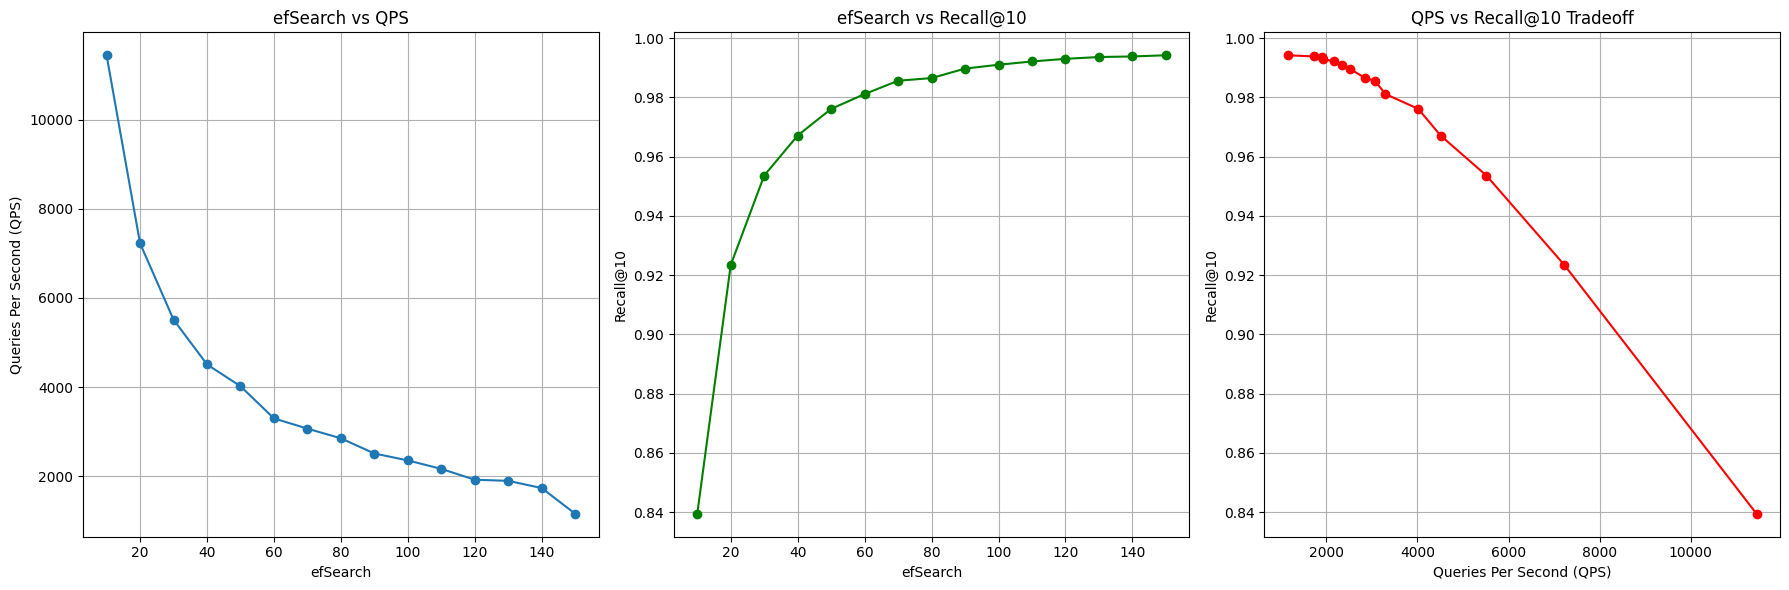

In [7]:
# @title
import faiss
import numpy as np
from pathlib import Path
import time
import matplotlib.pyplot as plt

# Helper functions (re-defined for self-contained cell)
def load_vector_bin(path: Path) -> np.ndarray:
    with path.open("rb") as f:
        n = int(np.fromfile(f, dtype=np.int64, count=1)[0])
        d = int(np.fromfile(f, dtype=np.int64, count=1)[0])
        vec = np.fromfile(f, dtype=np.float32, count=n * d).reshape(n, d)
    return vec

def recall_at_k(pred_ids: np.ndarray, gt_ids: np.ndarray, k: int) -> float:
    pred = np.asarray(pred_ids, dtype=np.int64)
    gt = np.asarray(gt_ids, dtype=np.int64)
    if pred.ndim != 2 or gt.ndim != 2:
        raise ValueError("pred_ids and gt_ids must be 2D arrays of shape (nq, k_or_more).")
    if pred.shape[0] != gt.shape[0]:
        raise ValueError("pred_ids and gt_ids must have the same number of queries.")

    vals = []
    for p, g in zip(pred, gt):
        vals.append(len(set(map(int, p[:k])).intersection(map(int, g[:k]))) / float(k))
    return float(np.mean(vals))

# --- Data Loading ---
xq_path = Path("/content/Drive_utils/data/queries_stemwiki_1000_384_norm.bin")
xb_path = Path("/content/Drive_utils/data/dataset_stemwiki_100000_384_norm.bin")
gt_ids_path = Path("/content/Drive_utils/data/gt_k10/gt_ids.npy")

xb = load_vector_bin(xb_path).astype(np.float32)
xq = load_vector_bin(xq_path).astype(np.float32)
gt_ids = np.load(gt_ids_path)

# Normalize once; then IP == cosine similarity.
xb /= np.maximum(np.linalg.norm(xb, axis=1, keepdims=True), 1e-12)
xq /= np.maximum(np.linalg.norm(xq, axis=1, keepdims=True), 1e-12)

# --- HNSW Index Configuration ---
d = xb.shape[1]  # Dimension of vectors
k = 10           # Number of nearest neighbors to retrieve
M = 24           # Number of bi-directional links per node
efConstruction = 64 # Size of the dynamic list during construction

# --- Index Building ---
print(f"Building HNSW index with M={M}, efConstruction={efConstruction}...")
index = faiss.IndexHNSWFlat(d, M, faiss.METRIC_INNER_PRODUCT)
index.hnsw.efConstruction = efConstruction

t0_build = time.perf_counter()
index.add(xb)
build_time = time.perf_counter() - t0_build
print(f"Index build time: {build_time:.4f} seconds")
print(f"Number of vectors in index: {index.ntotal}")

# --- Search Performance Evaluation ---
eSearch_taken_values = np.arange(10, 160, 10)

qps_results = []
recall_results = []
ef_search_results = []

print("\nEvaluating search performance for different efSearch values...")
print("----------------------------------------------------------------")
print(f"{'efSearch':<10} | {'QPS':<10} | {'Recall@10':<10}")
print("----------------------------------------------------------------")
for ef_search in eSearch_taken_values:
    index.hnsw.efSearch = int(ef_search)

    t0_search = time.perf_counter()
    distances, ids = index.search(xq, k)
    search_time = time.perf_counter() - t0_search

    qps = xq.shape[0] / search_time
    recall = recall_at_k(ids, gt_ids, k)

    qps_results.append(qps)
    recall_results.append(recall)
    ef_search_results.append(ef_search)
    print(f"{ef_search:<10} | {qps:<10.2f} | {recall:<10.4f}")
print("----------------------------------------------------------------")

# --- Plotting ---
plt.figure(figsize=(18, 6))

# Plot 1: efSearch vs QPS
plt.subplot(1, 3, 1)
plt.plot(ef_search_results, qps_results, marker='o')
plt.title('efSearch vs QPS')
plt.xlabel('efSearch')
plt.ylabel('Queries Per Second (QPS)')
plt.grid(True)

# Plot 2: efSearch vs Recall@10
plt.subplot(1, 3, 2)
plt.plot(ef_search_results, recall_results, marker='o', color='green')
plt.title('efSearch vs Recall@10')
plt.xlabel('efSearch')
plt.ylabel('Recall@10')
plt.grid(True)

# Plot 3: QPS vs Recall@10 (Tradeoff plot)
plt.subplot(1, 3, 3)
plt.plot(qps_results, recall_results, marker='o', color='red')
plt.title('QPS vs Recall@10 Tradeoff')
plt.xlabel('Queries Per Second (QPS)')
plt.ylabel('Recall@10')
plt.grid(True)

plt.tight_layout()
plt.show()

As expected the higher efConstruction the better the recall is at the cost of performance. At a certain point qps stagnate around 2000 querries per second, maybe the pile is not even used or just the algorithm finds less new 'interesing' path.

The algorithm expends more effort to find the optimal connections for each node for efConstruction, the better the recall (the saturation comes from the same reason).

The tradeoff is, consequently, stagnating for the lower qps and bad for higher (in a minus exponential way I think).



**FOR M ∈ {10,30,50,80,100,120} at fixed efConstruction and efSearch**

Evaluating HNSW index performance for varying M with efConstruction=64, efSearch=64...
--------------------------------------------------------------------------------
M     | Build Time (s)  | QPS        | Recall@10 
--------------------------------------------------------------------------------
10    | 32.5796         | 4361.78    | 0.9625    
30    | 36.2824         | 3167.87    | 0.9853    
50    | 59.1976         | 1913.86    | 0.9932    
80    | 69.7791         | 1480.77    | 0.9960    
100   | 76.4947         | 1322.48    | 0.9965    
120   | 79.4650         | 1236.94    | 0.9966    
--------------------------------------------------------------------------------


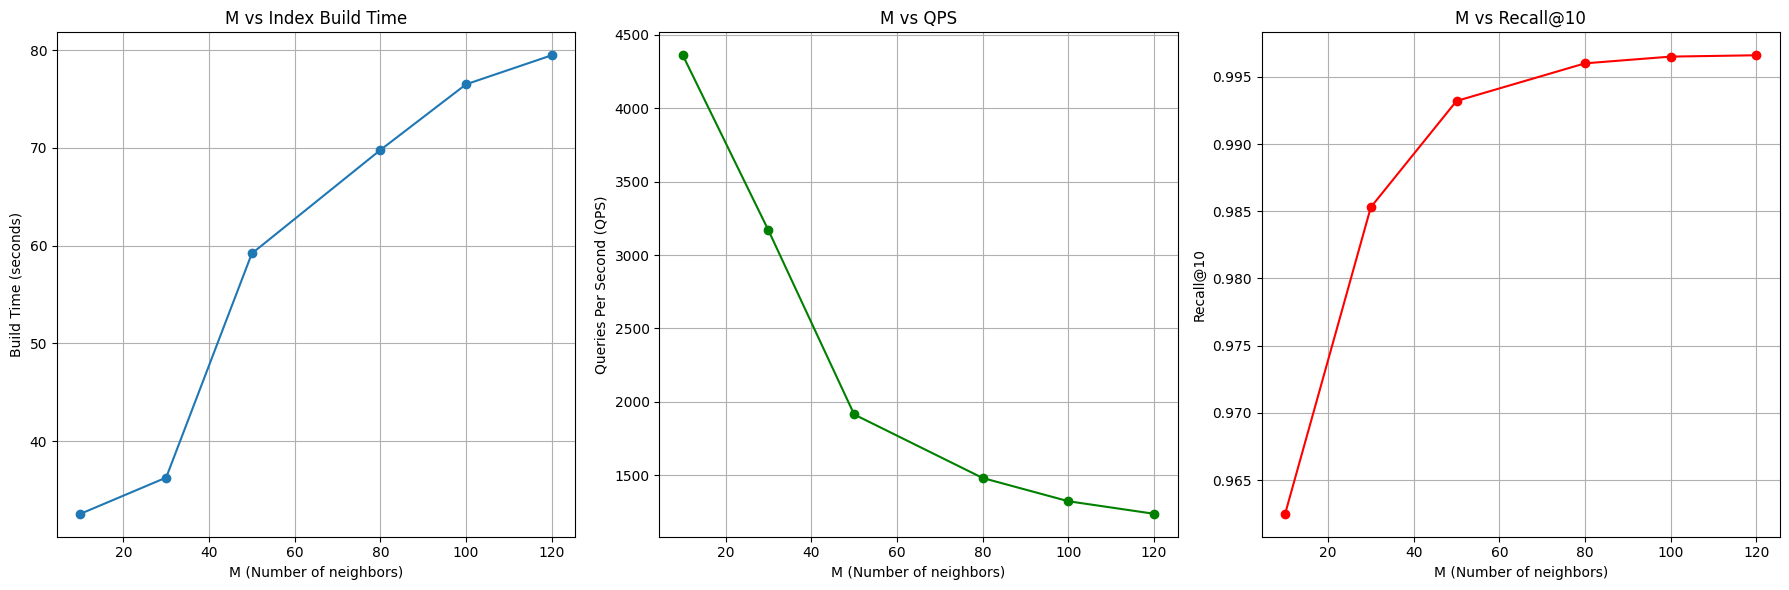

In [8]:
# @title
import faiss
import numpy as np
from pathlib import Path
import time
import matplotlib.pyplot as plt

# Helper functions (re-defined for self-contained cell)
def load_vector_bin(path: Path) -> np.ndarray:
    with path.open("rb") as f:
        n = int(np.fromfile(f, dtype=np.int64, count=1)[0])
        d = int(np.fromfile(f, dtype=np.int64, count=1)[0])
        vec = np.fromfile(f, dtype=np.float32, count=n * d).reshape(n, d)
    return vec

def recall_at_k(pred_ids: np.ndarray, gt_ids: np.ndarray, k: int) -> float:
    pred = np.asarray(pred_ids, dtype=np.int64)
    gt = np.asarray(gt_ids, dtype=np.int64)
    if pred.ndim != 2 or gt.ndim != 2:
        raise ValueError("pred_ids and gt_ids must be 2D arrays of shape (nq, k_or_more).")
    if pred.shape[0] != gt.shape[0]:
        raise ValueError("pred_ids and gt_ids must have the same number of queries.")

    vals = []
    for p, g in zip(pred, gt):
        vals.append(len(set(map(int, p[:k])).intersection(map(int, g[:k]))) / float(k))
    return float(np.mean(vals))

# --- Data Loading ---
xq_path = Path("/content/Drive_utils/data/queries_stemwiki_1000_384_norm.bin")
xb_path = Path("/content/Drive_utils/data/dataset_stemwiki_100000_384_norm.bin")
gt_ids_path = Path("/content/Drive_utils/data/gt_k10/gt_ids.npy")

xb = load_vector_bin(xb_path).astype(np.float32)
xq = load_vector_bin(xq_path).astype(np.float32)
gt_ids = np.load(gt_ids_path)

# Normalize once; then IP == cosine similarity.
xb /= np.maximum(np.linalg.norm(xb, axis=1, keepdims=True), 1e-12)
xq /= np.maximum(np.linalg.norm(xq, axis=1, keepdims=True), 1e-12)

# --- HNSW Index Configuration ---
d = xb.shape[1]  # Dimension of vectors
k = 10           # Number of nearest neighbors to retrieve
efConstruction = 64 # Fixed efConstruction
efSearch = 64       # Fixed efSearch for evaluation of M

# --- Search Performance Evaluation for different M values ---
M_taken_values = np.array([10, 30, 50, 80, 100, 120])

build_times = []
qps_results = []
recall_results = []
M_results = []

print(f"Evaluating HNSW index performance for varying M with efConstruction={efConstruction}, efSearch={efSearch}...")
print("--------------------------------------------------------------------------------")
print(f"{'M':<5} | {'Build Time (s)':<15} | {'QPS':<10} | {'Recall@10':<10}")
print("--------------------------------------------------------------------------------")

for M_val in M_taken_values:
    index = faiss.IndexHNSWFlat(d, int(M_val), faiss.METRIC_INNER_PRODUCT)
    index.hnsw.efConstruction = efConstruction

    t0_build = time.perf_counter()
    index.add(xb)
    build_time = time.perf_counter() - t0_build
    build_times.append(build_time)

    index.hnsw.efSearch = efSearch

    t0_search = time.perf_counter()
    distances, ids = index.search(xq, k)
    search_time = time.perf_counter() - t0_search

    qps = xq.shape[0] / search_time
    recall = recall_at_k(ids, gt_ids, k)

    qps_results.append(qps)
    recall_results.append(recall)
    M_results.append(M_val)

    print(f"{M_val:<5} | {build_time:<15.4f} | {qps:<10.2f} | {recall:<10.4f}")
print("--------------------------------------------------------------------------------")

# --- Plotting ---
plt.figure(figsize=(18, 6))

# Plot 1: M vs Build Time
plt.subplot(1, 3, 1)
plt.plot(M_results, build_times, marker='o')
plt.title('M vs Index Build Time')
plt.xlabel('M (Number of neighbors)')
plt.ylabel('Build Time (seconds)')
plt.grid(True)

# Plot 2: M vs QPS
plt.subplot(1, 3, 2)
plt.plot(M_results, qps_results, marker='o', color='green')
plt.title('M vs QPS')
plt.xlabel('M (Number of neighbors)')
plt.ylabel('Queries Per Second (QPS)')
plt.grid(True)

# Plot 3: M vs Recall@10
plt.subplot(1, 3, 3)
plt.plot(M_results, recall_results, marker='o', color='red')
plt.title('M vs Recall@10')
plt.xlabel('M (Number of neighbors)')
plt.ylabel('Recall@10')
plt.grid(True)

plt.tight_layout()
plt.show()

As expected the higher M the better the recall is at the cost of performance (time and memory). [less information lost by cutting nodes]



Performance wise takinga high efConstruction is way more pertinent than making M higher (slow down as much the QPS for way higher index_building time). However if we have to be higher than a designited threshold modifying M (slighly) could be convenient [for 0.95 we would lower M=24]



Evaluating efSearch for combined plot...
efSearch evaluation complete.

Evaluating M for combined plot...
M evaluation complete.


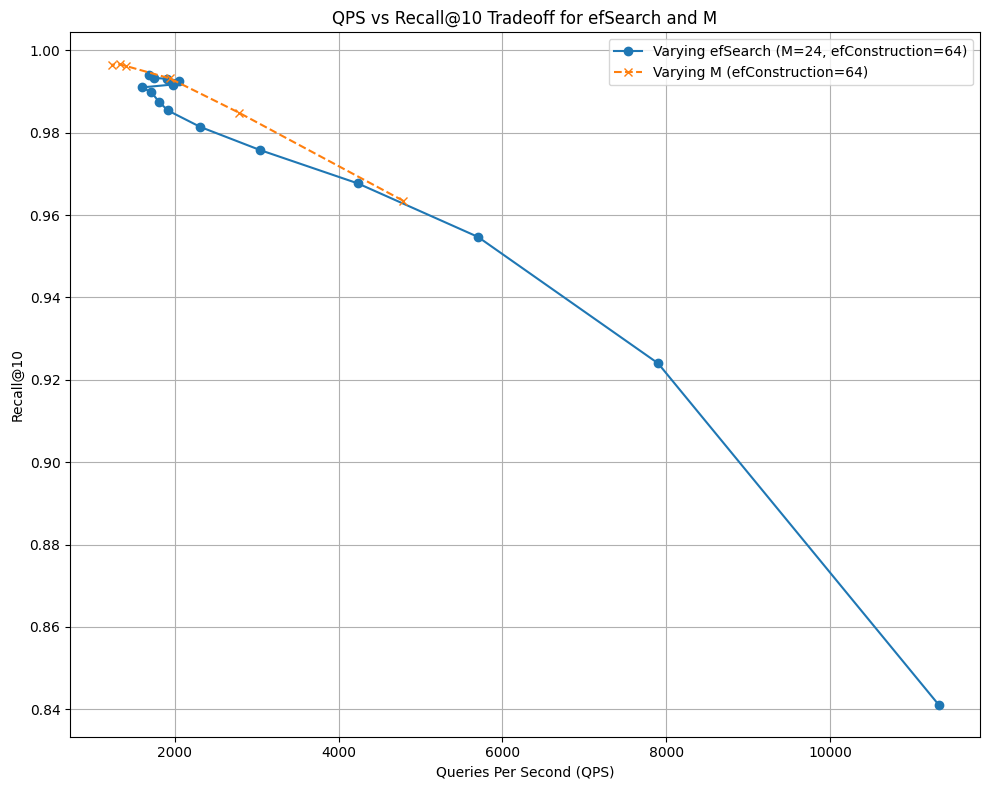

In [9]:
# @title
import faiss
import numpy as np
from pathlib import Path
import time
import matplotlib.pyplot as plt

# Helper functions (re-defined for self-contained cell, if not already in session)
def load_vector_bin(path: Path) -> np.ndarray:
    with path.open("rb") as f:
        n = int(np.fromfile(f, dtype=np.int64, count=1)[0])
        d = int(np.fromfile(f, dtype=np.int64, count=1)[0])
        vec = np.fromfile(f, dtype=np.float32, count=n * d).reshape(n, d)
    return vec

def recall_at_k(pred_ids: np.ndarray, gt_ids: np.ndarray, k: int) -> float:
    pred = np.asarray(pred_ids, dtype=np.int64)
    gt = np.asarray(gt_ids, dtype=np.int64)
    if pred.ndim != 2 or gt.ndim != 2:
        raise ValueError("pred_ids and gt_ids must be 2D arrays of shape (nq, k_or_more).")
    if pred.shape[0] != gt.shape[0]:
        raise ValueError("pred_ids and gt_ids must have the same number of queries.")

    vals = []
    for p, g in zip(pred, gt):
        vals.append(len(set(map(int, p[:k])).intersection(map(int, g[:k]))) / float(k))
    return float(np.mean(vals))

# --- Data Loading ---
xq_path = Path("/content/Drive_utils/data/queries_stemwiki_1000_384_norm.bin")
xb_path = Path("/content/Drive_utils/data/dataset_stemwiki_100000_384_norm.bin")
gt_ids_path = Path("/content/Drive_utils/data/gt_k10/gt_ids.npy")

xb = load_vector_bin(xb_path).astype(np.float32)
xq = load_vector_bin(xq_path).astype(np.float32)
gt_ids = np.load(gt_ids_path)

# Normalize once; then IP == cosine similarity.
xb /= np.maximum(np.linalg.norm(xb, axis=1, keepdims=True), 1e-12)
xq /= np.maximum(np.linalg.norm(xq, axis=1, keepdims=True), 1e-12)

# --- Parameters ---
d = xb.shape[1]
k = 10

# --- Evaluate efSearch impact (fixed M, efConstruction) ---
M_fixed_efSearch = 24
efConstruction_fixed_efSearch = 64
eSearch_taken_values = np.arange(10, 160, 10)

qps_efsearch_results = []
recall_efsearch_results = []

print("Evaluating efSearch for combined plot...")
index_efsearch = faiss.IndexHNSWFlat(d, M_fixed_efSearch, faiss.METRIC_INNER_PRODUCT)
index_efsearch.hnsw.efConstruction = efConstruction_fixed_efSearch
index_efsearch.add(xb)

for ef_search in eSearch_taken_values:
    index_efsearch.hnsw.efSearch = int(ef_search)
    t0_search = time.perf_counter()
    _, ids = index_efsearch.search(xq, k)
    search_time = time.perf_counter() - t0_search
    qps_efsearch_results.append(xq.shape[0] / search_time)
    recall_efsearch_results.append(recall_at_k(ids, gt_ids, k))
print("efSearch evaluation complete.")

# --- Evaluate M impact (fixed efConstruction, efSearch) ---
efConstruction_fixed_M = 64
efSearch_fixed_M = 64
M_taken_values = np.array([10, 30, 50, 80, 100, 120])

qps_M_results = []
recall_M_results = []

print("\nEvaluating M for combined plot...")
for M_val in M_taken_values:
    index_M = faiss.IndexHNSWFlat(d, int(M_val), faiss.METRIC_INNER_PRODUCT)
    index_M.hnsw.efConstruction = efConstruction_fixed_M
    index_M.add(xb)
    index_M.hnsw.efSearch = efSearch_fixed_M
    t0_search = time.perf_counter()
    _, ids = index_M.search(xq, k)
    search_time = time.perf_counter() - t0_search
    qps_M_results.append(xq.shape[0] / search_time)
    recall_M_results.append(recall_at_k(ids, gt_ids, k))
print("M evaluation complete.")

# --- Combined Plotting ---
plt.figure(figsize=(10, 8))
plt.plot(qps_efsearch_results, recall_efsearch_results, marker='o', label='Varying efSearch (M=24, efConstruction=64)')
plt.plot(qps_M_results, recall_M_results, marker='x', label='Varying M (efConstruction=64)', linestyle='--')

plt.title('QPS vs Recall@10 Tradeoff for efSearch and M')
plt.xlabel('Queries Per Second (QPS)')
plt.ylabel('Recall@10')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()




---


**Part 2: IVF– Probing Tradeof**

In [10]:
# @title
#!/usr/bin/env python3
from pathlib import Path

import faiss
import numpy as np


def main() -> None:
    n = 10_000
    nq = 100
    d = 384  # Changed from 64 to 384 to match the actual data dimension
    k = 10

    # rng = np.random.default_rng(123)
    xb = load_vector_bin(Path("/content/Drive_utils/data/dataset_stemwiki_100000_384_norm.bin")).astype(np.float32)
    xq = load_vector_bin(Path("/content/Drive_utils/data/queries_stemwiki_1000_384_norm.bin")).astype(np.float32)

    # Normalize once; then IP == cosine similarity.
    xb /= np.maximum(np.linalg.norm(xb, axis=1, keepdims=True), 1e-12)
    xq /= np.maximum(np.linalg.norm(xq, axis=1, keepdims=True), 1e-12)

    quantizer = faiss.IndexFlatIP(d)
    index = faiss.IndexIVFFlat(quantizer, d, 1024, faiss.METRIC_INNER_PRODUCT)
    index.train(xb)
    index.add(xb)
    index.nprobe = 64

    out_dir = Path("examples/indices")
    out_dir.mkdir(parents=True, exist_ok=True)
    index_path = out_dir / "ivf_10k_ip.faiss"
    faiss.write_index(index, str(index_path))

    reloaded = faiss.read_index(str(index_path))
    reloaded.nprobe = 64
    _, ids = reloaded.search(xq, k)

    print(f"Index saved to: {index_path}")
    print(f"Metric: IP (with normalized vectors)")
    print(f"Search results shape: {ids.shape}")
    print("Top-10 ids for each query:")
    for qi, row in enumerate(ids):
        print(f"q{qi:03d}: {row.tolist()}")


main()


Index saved to: examples/indices/ivf_10k_ip.faiss
Metric: IP (with normalized vectors)
Search results shape: (1000, 10)
Top-10 ids for each query:
q000: [94294, 13001, 32999, 70318, 48506, 90802, 41324, 66015, 99862, 73247]
q001: [56141, 24489, 35271, 16525, 3275, 73758, 120, 62583, 33431, 75292]
q002: [54747, 7309, 41745, 38142, 71770, 1725, 71196, 56759, 42871, 34926]
q003: [67473, 24756, 26415, 31284, 8902, 93954, 90346, 17171, 19906, 95058]
q004: [29976, 80001, 21640, 84797, 12039, 1160, 97754, 66629, 67387, 28690]
q005: [62478, 59762, 62133, 56196, 11929, 52159, 57130, 84176, 57230, 44609]
q006: [96397, 36152, 54444, 3201, 64147, 4185, 42231, 81386, 55664, 99553]
q007: [19355, 91402, 24130, 62509, 35239, 53834, 22217, 95204, 32265, 2775]
q008: [83667, 9494, 33218, 67324, 32642, 43711, 66576, 54359, 70407, 85702]
q009: [27147, 27704, 50600, 91221, 6471, 24487, 11076, 19379, 59088, 15300]
q010: [11351, 45771, 63191, 3369, 39543, 48727, 22706, 86276, 42820, 29124]
q011: [796, 39112, 

Building IVF index with nlist=1024...
Index build time: 16.4589 seconds
Number of vectors in index: 100000

Evaluating search performance for different nprobe values...
----------------------------------------------------------------
nprobe     | QPS        | Recall@10 
----------------------------------------------------------------
10         | 5660.19    | 0.8372    
20         | 3439.75    | 0.9124    
30         | 2320.33    | 0.9420    
40         | 1745.17    | 0.9576    
50         | 1383.46    | 0.9684    
60         | 1221.02    | 0.9747    
70         | 1000.91    | 0.9795    
80         | 643.71     | 0.9825    
90         | 582.96     | 0.9858    
100        | 706.27     | 0.9877    
110        | 668.03     | 0.9889    
120        | 613.33     | 0.9900    
130        | 571.31     | 0.9908    
140        | 517.71     | 0.9914    
150        | 466.82     | 0.9918    
160        | 337.14     | 0.9921    
170        | 418.92     | 0.9929    
180        | 410.24     | 0.9938   

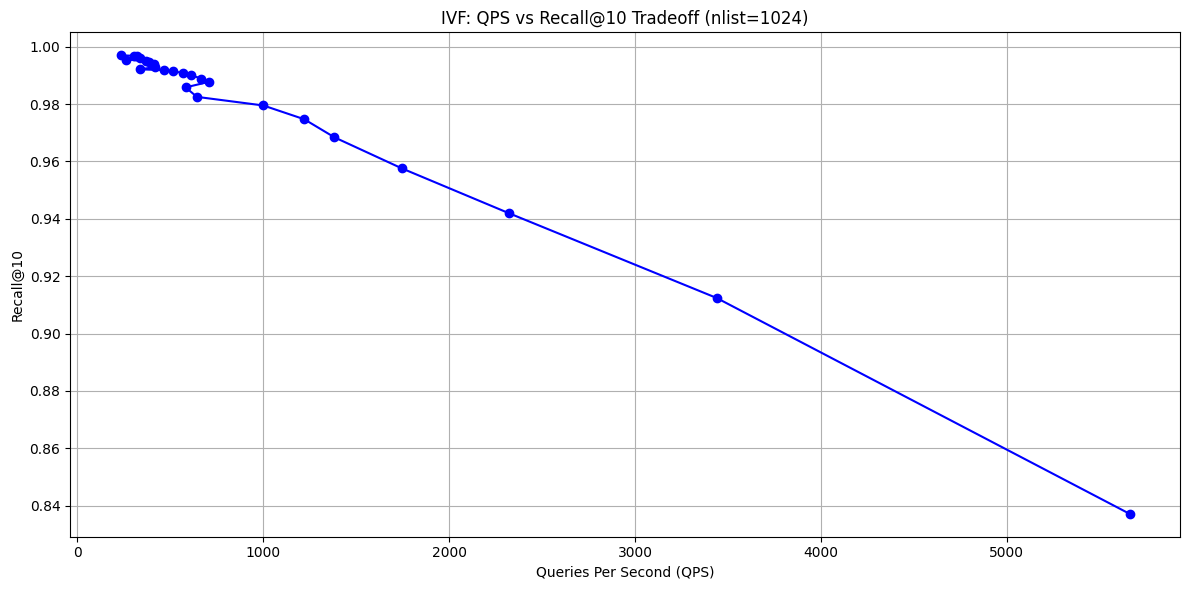

In [11]:
# @title
# --- Data Loading ---
xq_path = Path("/content/Drive_utils/data/queries_stemwiki_1000_384_norm.bin")
xb_path = Path("/content/Drive_utils/data/dataset_stemwiki_100000_384_norm.bin")
gt_ids_path = Path("/content/Drive_utils/data/gt_k10/gt_ids.npy")

xb = load_vector_bin(xb_path).astype(np.float32)
xq = load_vector_bin(xq_path).astype(np.float32)
gt_ids = np.load(gt_ids_path)

# Normalize once; then IP == cosine similarity.
xb /= np.maximum(np.linalg.norm(xb, axis=1, keepdims=True), 1e-12)
xq /= np.maximum(np.linalg.norm(xq, axis=1, keepdims=True), 1e-12)

# --- IVF Index Configuration ---
d = xb.shape[1]  # Dimension of vectors
k = 10           # Number of nearest neighbors to retrieve
nlist = 1024     # Number of centroids (clusters)

# --- Index Building ---
print(f"Building IVF index with nlist={nlist}...")
quantizer = faiss.IndexFlatIP(d)
index = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_INNER_PRODUCT)

t0_train = time.perf_counter()
index.train(xb)
index.add(xb)
build_time = time.perf_counter() - t0_train
print(f"Index build time: {build_time:.4f} seconds")
print(f"Number of vectors in index: {index.ntotal}")

# --- Search Performance Evaluation ---
nprobe_taken_values = np.arange(10, 257, 10)

qps_results = []
recall_results = []
nprobe_results = []

print("\nEvaluating search performance for different nprobe values...")
print("----------------------------------------------------------------")
print(f"{'nprobe':<10} | {'QPS':<10} | {'Recall@10':<10}")
print("----------------------------------------------------------------")
for nprobe_val in nprobe_taken_values:
    index.nprobe = int(nprobe_val)

    t0_search = time.perf_counter()
    distances, ids = index.search(xq, k)
    search_time = time.perf_counter() - t0_search

    qps = xq.shape[0] / search_time
    recall = recall_at_k(ids, gt_ids, k)

    qps_results.append(qps)
    recall_results.append(recall)
    nprobe_results.append(nprobe_val)
    print(f"{nprobe_val:<10} | {qps:<10.2f} | {recall:<10.4f}")
print("----------------------------------------------------------------")

# --- Plotting ---
plt.figure(figsize=(12, 6))

# Plot QPS vs Recall@10 (Tradeoff plot)
plt.plot(qps_results, recall_results, marker='o', color='blue')
plt.title('IVF: QPS vs Recall@10 Tradeoff (nlist=1024)')
plt.xlabel('Queries Per Second (QPS)')
plt.ylabel('Recall@10')
plt.grid(True)
plt.tight_layout()
plt.show()


The higher nprobe the more cluster the vector space is divided by so the better reacall we have. However the more the cluster the more computational load we have (qps decrease).






### Explanation of IVF Index Construction and Search (given by Gemini)

**Inverted File Index (IVF)** is an Approximate Nearest Neighbor (ANN) search algorithm designed to speed up searches in large datasets by partitioning the data into clusters.

Here's a breakdown of how it works:

1.  **Quantizer (Clustering)**:
    *   The first step is to train a `quantizer`. This quantizer is typically a clustering algorithm (like K-means) that divides the entire dataset (`xb`) into `nlist` (number of lists or clusters) Voronoi cells. Each cell is represented by a centroid vector.
    *   During the `index.train(xb)` step, the algorithm learns these `nlist` centroids.

2.  **Assignment to Lists (Inverted File Structure)**:
    *   After training, each vector in the dataset (`xb`) is assigned to its closest centroid. Instead of storing all vectors sequentially, the IVF index stores an "inverted file" list for each centroid. This list contains the IDs of all data points that belong to that centroid's cluster.
    *   This effectively partitions the large dataset into `nlist` smaller, more manageable sub-indexes. This step happens during `index.add(xb)`.

3.  **Search Phase (`nprobe` parameter)**:
    *   When a query vector (`xq`) comes in, the IVF index first identifies the `nprobe` (number of probes) closest centroids to the query vector. `nprobe` is a crucial parameter that controls the search accuracy and speed tradeoff.
    *   Instead of searching the entire dataset, the algorithm only searches through the inverted lists corresponding to these `nprobe` closest centroids.
    *   It retrieves the `k` (number of nearest neighbors requested) closest vectors from the combined set of vectors found in these `nprobe` lists.

**Part 3: Explanation IVFPQ and IVFOPQ – Compression and Accuracy**

In [12]:
# @title
import faiss
import numpy as np
from pathlib import Path
import time
import matplotlib.pyplot as plt

# Helper functions (re-defined for self-contained cell)
def load_vector_bin(path: Path) -> np.ndarray:
    with path.open("rb") as f:
        n = int(np.fromfile(f, dtype=np.int64, count=1)[0])
        d = int(np.fromfile(f, dtype=np.int64, count=1)[0])
        vec = np.fromfile(f, dtype=np.float32, count=n * d).reshape(n, d)
    return vec

def recall_at_k(pred_ids: np.ndarray, gt_ids: np.ndarray, k: int) -> float:
    pred = np.asarray(pred_ids, dtype=np.int64)
    gt = np.asarray(gt_ids, dtype=np.int64)
    if pred.ndim != 2 or gt.ndim != 2:
        raise ValueError("pred_ids and gt_ids must be 2D arrays of shape (nq, k_or_more).")
    if pred.shape[0] != gt.shape[0]:
        raise ValueError("pred_ids and gt_ids must have the same number of queries.")

    vals = []
    for p, g in zip(pred, gt):
        vals.append(len(set(map(int, p[:k])).intersection(map(int, g[:k]))) / float(k))
    return float(np.mean(vals))

# --- Data Loading ---
xq_path = Path("/content/Drive_utils/data/queries_stemwiki_1000_384_norm.bin")
xb_path = Path("/content/Drive_utils/data/dataset_stemwiki_100000_384_norm.bin")
gt_ids_path = Path("/content/Drive_utils/data/gt_k10/gt_ids.npy")

xb = load_vector_bin(xb_path).astype(np.float32)
xq = load_vector_bin(xq_path).astype(np.float32)
gt_ids = np.load(gt_ids_path)

# Normalize once; then IP == cosine similarity.
xb /= np.maximum(np.linalg.norm(xb, axis=1, keepdims=True), 1e-12)
xq /= np.maximum(np.linalg.norm(xq, axis=1, keepdims=True), 1e-12)

# --- IVFPQ Baseline Configuration ---
d = xb.shape[1]  # Dimension of vectors
k = 10           # Number of nearest neighbors to retrieve
nlist = 1024     # Number of coarse clusters
m = 32           # Number of subquantizers
nbits = 8        # Number of bits per subquantizer
nprobe = 64      # Fixed nprobe for baseline evaluation

print(f"Building IVFPQ index with nlist={nlist}, m={m}, nbits={nbits}...")

# 1. Coarse Quantizer (IndexFlatIP for inner product)
quantizer = faiss.IndexFlatIP(d)

# 2. IVFPQ Index
# index_factory is a convenient way to create complex indices
# "IVF1024,PQ32x8" means IVF with 1024 lists, and PQ with 32 subvectors, 8 bits each
index_ivfpq = faiss.index_factory(d, f"IVF{nlist},PQ{m}x{nbits}", faiss.METRIC_INNER_PRODUCT)

# Check if the index is trained (needs to be trained on representative data)
if not index_ivfpq.is_trained:
    print("Training IVFPQ index...")
    t0_train = time.perf_counter()
    index_ivfpq.train(xb)
    train_time = time.perf_counter() - t0_train
    print(f"IVFPQ training time: {train_time:.4f} seconds")

t0_add = time.perf_counter()
index_ivfpq.add(xb)
add_time = time.perf_counter() - t0_add
print(f"IVFPQ add time: {add_time:.4f} seconds")
print(f"Number of vectors in IVFPQ index: {index_ivfpq.ntotal}")

# Set nprobe for search
index_ivfpq.nprobe = nprobe

# --- Search Performance Evaluation for IVFPQ Baseline ---
t0_search = time.perf_counter()
distances_ivfpq, ids_ivfpq = index_ivfpq.search(xq, k)
search_time_ivfpq = time.perf_counter() - t0_search

qps_ivfpq = xq.shape[0] / search_time_ivfpq
recall_ivfpq = recall_at_k(ids_ivfpq, gt_ids, k)

print("\n--- IVFPQ Baseline Results ---")
print(f"nlist: {nlist}, m: {m}, nbits: {nbits}, nprobe: {nprobe}")
print(f"Total Indexing Time (train + add): {(train_time + add_time):.4f} seconds")
print(f"QPS: {qps_ivfpq:.2f}")
print(f"Recall@10: {recall_ivfpq:.4f}")

# Calculate approximate memory usage (PQ codes + centroids)
# Size of PQ codes: n_vectors * (m * nbits / 8) bytes
pq_codes_memory_bytes = index_ivfpq.ntotal * (m * nbits / 8)
# Size of centroids: nlist * d * 4 bytes (for float32)
centroids_memory_bytes = nlist * d * 4
total_approx_memory_mb = (pq_codes_memory_bytes + centroids_memory_bytes) / (1024 * 1024)
print(f"Approximate Memory Usage (PQ codes + centroids): {total_approx_memory_mb:.2f} MB")


Building IVFPQ index with nlist=1024, m=32, nbits=8...
Training IVFPQ index...
IVFPQ training time: 153.9774 seconds
IVFPQ add time: 4.9891 seconds
Number of vectors in IVFPQ index: 100000

--- IVFPQ Baseline Results ---
nlist: 1024, m: 32, nbits: 8, nprobe: 64
Total Indexing Time (train + add): 158.9666 seconds
QPS: 3195.52
Recall@10: 0.5526
Approximate Memory Usage (PQ codes + centroids): 4.55 MB


In [19]:
import faiss
import numpy as np
from pathlib import Path
import time

# Helper functions are assumed to be defined from previous cell or session
# load_vector_bin and recall_at_k

# --- Data Loading (re-load if not in session to ensure independence) ---
xq_path = Path("/content/Drive_utils/data/queries_stemwiki_1000_384_norm.bin")
xb_path = Path("/content/Drive_utils/data/dataset_stemwiki_100000_384_norm.bin")
gt_ids_path = Path("/content/Drive_utils/data/gt_k10/gt_ids.npy")

xb = load_vector_bin(xb_path).astype(np.float32)
xq = load_vector_bin(xq_path).astype(np.float32)
gt_ids = np.load(gt_ids_path)

# Normalize once; then IP == cosine similarity.
xb /= np.maximum(np.linalg.norm(xb, axis=1, keepdims=True), 1e-12)
xq /= np.maximum(np.linalg.norm(xq, axis=1, keepdims=True), 1e-12)

# --- IVFOPQ Baseline Configuration ---
d = xb.shape[1]  # Dimension of vectors
k = 10           # Number of nearest neighbors to retrieve
nlist = 1024     # Number of coarse clusters
m = 32           # Number of subquantizers
nbits = 8        # Number of bits per subquantizer
nprobe = 64      # Fixed nprobe for baseline evaluation

print(f"Building IVFOPQ index with nlist={nlist}, m={m}, nbits={nbits}...")

# 1. Coarse Quantizer (IndexFlatIP for inner product)
quantizer = faiss.IndexFlatIP(d)

# 2. IVFOPQ Index
# "OPQ{m},IVF{nlist},PQ{m}x{nbits}" means Optimized Product Quantization applied,
# projecting to 'm' dimensions, then IVF with 'nlist' lists,
# and PQ with 'm' subvectors, 'nbits' each.
index_ivfopq = faiss.index_factory(d, f"OPQ{m},IVF{nlist},PQ{m}x{nbits}", faiss.METRIC_INNER_PRODUCT)

# Check if the index is trained (needs to be trained on representative data)
if not index_ivfopq.is_trained:
    print("Training IVFOPQ index...")
    t0_train = time.perf_counter()
    index_ivfopq.train(xb)
    train_time = time.perf_counter() - t0_train
    print(f"IVFOPQ training time: {train_time:.4f} seconds")

t0_add = time.perf_counter()
index_ivfopq.add(xb)
add_time = time.perf_counter() - t0_add
print(f"IVFOPQ add time: {add_time:.4f} seconds")
print(f"Number of vectors in IVFOPQ index: {index_ivfopq.ntotal}")

# Set nprobe for search. The IVF component is nested within the IndexPreTransform.
# Using faiss.extract_index_ivf for robust access to the IVF component's nprobe.
faiss.extract_index_ivf(index_ivfopq).nprobe = nprobe

# --- Search Performance Evaluation for IVFOPQ Baseline ---
t0_search = time.perf_counter()
distances_ivfopq, ids_ivfopq = index_ivfopq.search(xq, k)
search_time_ivfopq = time.perf_counter() - t0_search

qps_ivfopq = xq.shape[0] / search_time_ivfopq
recall_ivfopq = recall_at_k(ids_ivfopq, gt_ids, k)

print("\n--- IVFOPQ Baseline Results ---")
print(f"nlist: {nlist}, m: {m}, nbits: {nbits}, nprobe: {nprobe}")
print(f"Total Indexing Time (train + add): {(train_time + add_time):.4f} seconds")
print(f"QPS: {qps_ivfopq:.2f}")
print(f"Recall@10: {recall_ivfopq:.4f}")

# Calculate approximate memory usage (PQ codes + centroids)
# Size of PQ codes: n_vectors * (m * nbits / 8) bytes
pq_codes_memory_bytes = index_ivfopq.ntotal * (m * nbits / 8)
# Size of centroids: nlist * d * 4 bytes (for float32)
centroids_memory_bytes = nlist * d * 4
# Plus orthogonal transformation matrix (d * d * 4 bytes for float32)
# This is a rough estimate; Faiss might optimize storage.
transformation_matrix_memory_bytes = d * d * 4
total_approx_memory_mb = (pq_codes_memory_bytes + centroids_memory_bytes + transformation_matrix_memory_bytes) / (1024 * 1024)
print(f"Approximate Memory Usage (PQ codes + centroids + transformation): {total_approx_memory_mb:.2f} MB")


Building IVFOPQ index with nlist=1024, m=32, nbits=8...
Training IVFOPQ index...
IVFOPQ training time: 379.8155 seconds
IVFOPQ add time: 4.2161 seconds
Number of vectors in IVFOPQ index: 100000

--- IVFOPQ Baseline Results ---
nlist: 1024, m: 32, nbits: 8, nprobe: 64
Total Indexing Time (train + add): 384.0316 seconds
QPS: 3186.40
Recall@10: 0.6340
Approximate Memory Usage (PQ codes + centroids + transformation): 5.11 MB


In [ ]:
# --- Data Loading ---
xq_path = Path("/content/Drive_utils/data/queries_stemwiki_1000_384_norm.bin")
xb_path = Path("/content/Drive_utils/data/dataset_stemwiki_100000_384_norm.bin")
gt_ids_path = Path("/content/Drive_utils/data/gt_k10/gt_ids.npy")

xb = load_vector_bin(xb_path).astype(np.float32)
xq = load_vector_bin(xq_path).astype(np.float32)
gt_ids = np.load(gt_ids_path)

# Normalize once; then IP == cosine similarity.
xb /= np.maximum(np.linalg.norm(xb, axis=1, keepdims=True), 1e-12)
xq /= np.maximum(np.linalg.norm(xq, axis=1, keepdims=True), 1e-12)

# --- Common Configuration ---
d = xb.shape[1]  # Dimension of vectors
k = 10           # Number of nearest neighbors to retrieve
nlist = 1024     # Number of coarse clusters
nprobe = 64      # Fixed nprobe for consistency
m_values = [32, 16, 8] # Explicitly define m_values
nbits_values = [3,2] # Explicitly define nbits_values

def evaluate_index(index_type, m, nbits):
    print(f"\nEvaluating {index_type} with m={m}, nbits={nbits}...")
    factory_string = ""
    if index_type == "IVFPQ":
        factory_string = f"IVF{nlist},PQ{m}x{nbits}"
    elif index_type == "IVFOPQ":
        factory_string = f"OPQ{m},IVF{nlist},PQ{m}x{nbits}"
    else:
        raise ValueError("Invalid index_type. Use 'IVFPQ' or 'IVFOPQ'.")

    index = faiss.index_factory(d, factory_string, faiss.METRIC_INNER_PRODUCT)

    t0_train = time.perf_counter()
    index.train(xb)
    train_time = time.perf_counter() - t0_train

    t0_add = time.perf_counter()
    index.add(xb)
    add_time = time.perf_counter() - t0_add

    # Set nprobe for the IVF component (handling composite indices)
    if hasattr(index, 'nprobe'): # Direct IndexIVF or similar
        index.nprobe = nprobe
    elif hasattr(index, 'index') and hasattr(index.index, 'nprobe'): # IndexPreTransform wrapping IndexIVF
        faiss.extract_index_ivf(index).nprobe = nprobe # Use extract_index_ivf for robustness
    else:
        print(f"Warning: Could not set nprobe for {index_type} index with m={m}, nbits={nbits}. Assuming default.")

    t0_search = time.perf_counter()
    distances, ids = index.search(xq, k)
    search_time = time.perf_counter() - t0_search

    qps = xq.shape[0] / search_time
    recall = recall_at_k(ids, gt_ids, k)

    # Calculate approximate memory usage (PQ codes + centroids)
    pq_codes_memory_bytes = index.ntotal * (m * nbits / 8)
    centroids_memory_bytes = nlist * d * 4
    transformation_matrix_memory_bytes = 0
    if index_type == "IVFOPQ":
        # Rough estimate for OPQ transformation matrix
        transformation_matrix_memory_bytes = d * d * 4
    total_approx_memory_mb = (pq_codes_memory_bytes + centroids_memory_bytes + transformation_matrix_memory_bytes) / (1024 * 1024)

    print(f"  Indexing Time: {(train_time + add_time):.4f} s")
    print(f"  QPS: {qps:.2f}")
    print(f"  Recall@10: {recall:.4f}")
    print(f"  Approx. Memory: {total_approx_memory_mb:.2f} MB")

    return {
        'm': m, 'nbits': nbits, 'index_type': index_type,
        'indexing_time': train_time + add_time, 'qps': qps,
        'recall': recall, 'memory_mb': total_approx_memory_mb
    }

# results_ivfpq = []
# print("--- IVFPQ Parameter Sensitivity ---")
# for m_val in m_values:
#     for nbits_val in nbits_values:
#         if m_val * nbits_val > d * 8: # Ensure total bits for PQ don't exceed original vector bits
#             print(f"  Skipping IVFPQ with m={m_val}, nbits={nbits_val}: PQ total bits too high for dimension d={d}.")
#             continue
#         results_ivfpq.append(evaluate_index("IVFPQ", m_val, nbits_val))

results_ivfopq = []
print("\n--- IVFOPQ Parameter Sensitivity ---")
for m_val in m_values:
    for nbits_val in nbits_values:
        if m_val * nbits_val > d * 8: # Ensure total bits for PQ don't exceed original vector bits
            print(f"  Skipping IVFOPQ with m={m_val}, nbits={nbits_val}: PQ total bits too high for dimension d={d}.")
            continue
        # For IVFOPQ, m should also be a divisor of d
        if d % m_val != 0:
            print(f"  Skipping IVFOPQ with m={m_val}, nbits={nbits_val}: m must be a divisor of d ({d}).")
            continue
        results_ivfopq.append(evaluate_index("IVFOPQ", m_val, nbits_val))
print("IVFOPQ evaluation complete.")

# --- Plotting Results ---
# Adjusted for single column IVFOPQ plots
fig, axs = plt.subplots(3, 1, figsize=(10, 18))
fig.suptitle('IVFOPQ: Parameter Sensitivity (nlist=1024, nprobe=64)', fontsize=16)

def plot_results(ax, data, x_key, y_key, title, x_label, y_label):
    m_colors = {32: 'blue', 16: 'green', 8: 'red'}
    for m_val in m_values:
        m_data = [res for res in data if res['m'] == m_val]
        if m_data:
            x = [res[x_key] for res in m_data]
            y = [res[y_key] for res in m_data]
            nbits_labels = [str(res['nbits']) for res in m_data]
            ax.plot(x, y, marker='o', linestyle='-', color=m_colors[m_val], label=f'm={m_val}')
            for i, txt in enumerate(nbits_labels):
                ax.annotate(txt, (x[i], y[i]), textcoords="offset points", xytext=(0,5), ha='center')
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.grid(True)
    ax.legend()

# IVFOPQ Plots (using single column axs)
plot_results(axs[0], results_ivfopq, 'recall', 'qps', 'IVFOPQ: Recall@10 vs QPS', 'Recall@10', 'QPS')
plot_results(axs[1], results_ivfopq, 'memory_mb', 'qps', 'IVFOPQ: Memory vs QPS', 'Memory (MB)', 'QPS')
plot_results(axs[2], results_ivfopq, 'recall', 'memory_mb', 'IVFOPQ: Recall@10 vs Memory', 'Recall@10', 'Memory (MB)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


--- IVFOPQ Parameter Sensitivity ---

Evaluating IVFOPQ with m=32, nbits=3...
  Indexing Time: 264.0915 s
  QPS: 28617.69
  Recall@10: 0.2682
  Approx. Memory: 3.21 MB

Evaluating IVFOPQ with m=32, nbits=2...
  Indexing Time: 251.4075 s
  QPS: 30229.18
  Recall@10: 0.2209
  Approx. Memory: 2.83 MB

Evaluating IVFOPQ with m=16, nbits=3...
  Indexing Time: 307.0813 s
  QPS: 33838.16
  Recall@10: 0.1922
  Approx. Memory: 2.63 MB

Evaluating IVFOPQ with m=16, nbits=2...
  Indexing Time: 314.5358 s
  QPS: 19378.99
  Recall@10: 0.1553
  Approx. Memory: 2.44 MB

Evaluating IVFOPQ with m=8, nbits=3...


The code is way too slow to be studied. As m and nbits gets higher it makes the programm slower (qps is stagnant). (but not the last one ?)

Explanation IVFPQ and IVFOPQ – Compression and Accuracy (given by Gemini)

**IVF with Product Quantization (IVFPQ)** is an extension of the IVF index that further compresses the data vectors stored within each inverted list, significantly reducing memory footprint and improving search speed, especially for high-dimensional data.

Here's how it works:

1.  **Quantizer (Coarse Quantization)**:
    *   Similar to plain IVF, a coarse quantizer (e.g., `IndexFlatL2` or `IndexFlatIP`) is trained on the dataset to partition the vector space into `nlist` Voronoi cells. Each vector is assigned to its closest centroid.

2.  **Product Quantization (Fine Quantization)**:
    *   Instead of storing the original vectors in each inverted list, IVFPQ applies **Product Quantization**. Each full-dimensional vector is divided into `m` subvectors. For each subvector, a small, independent codebook is learned. Each subvector is then replaced by an index pointing to its closest entry in its corresponding codebook.
    *   This converts a high-dimensional float vector into a short sequence of integers (the PQ codes). This greatly compresses the data, as only these short codes are stored.

3.  **Search Phase**:
    *   When a query vector comes in, it's first coarsely quantized to identify the `nprobe` closest inverted lists.
    *   Within these selected lists, instead of computing distances to full vectors, IVFPQ uses an approximate distance calculation based on the PQ codes. The most common is the Asymmetric Distance Computation (ADC), which calculates the distance between the full query vector and the reconstructed vectors from the PQ codes. This is much faster than computing distances to original full vectors.

**Key Parameters for IVFPQ:**
*   `nlist`: Number of coarse clusters (same as IVF).
*   `m`: Number of subquantizers (number of parts each vector is split into). Higher `m` generally leads to better accuracy but higher memory and slower search (more lookups in codebooks).
*   `nbits`: Number of bits used for each subquantizer's codebook. This determines the size of each subvector's codebook (e.g., `nbits=8` means 2^8 = 256 entries per codebook). Higher `nbits` means better precision but slightly larger codebooks.

**IVF with Optimized Product Quantization (IVFOPQ)** is an enhancement over IVFPQ that aims to improve the effectiveness of Product Quantization by applying an orthogonal transformation (rotation) to the data *before* Product Quantization. This transformation attempts to decorrelate the dimensions of the vectors, making them more suitable for PQ compression.

**How IVFOPQ differs from IVFPQ:**
1.  **Pre-processing (Orthogonal Transformation)**:
    *   Before the coarse quantization (IVF part) and product quantization, IVFOPQ trains an orthogonal matrix. This matrix is used to rotate the input vectors. The goal is to make the subvectors created by PQ as independent as possible, thus improving the accuracy of PQ compression.

2.  **Subsequent Steps**:
    *   After the transformation, the process largely follows IVFPQ: coarse quantization into `nlist` cells, followed by product quantization into `m` subquantizers with `nbits` per codebook within each cell.

**Part 4: Final Cross-Method Comparison**

NOT DONE